In [53]:
import numpy as np
import matplotlib.pyplot as plt

In [54]:
class Spring():
    def __init__ (self, k=1, x0 =0):
        self.k = k
        self.x0 = x0

    # to be used in the MC
    def potential_energy(self, x):
        return 0.5*self.k*(x-self.x0)**2
    
    # to be used in the MD
    def metropolis_mc(self, kbT, n_steps=200000, delta=0.5, x_init=0.0):
        x = x_init
        energies = np.empty(n_steps)
        positions = np.empty(n_steps)
        for i in range(n_steps):
            x_trial = x + np.random.uniform(-delta, delta)
            dE = self.potential_energy(x_trial) - self.potential_energy(x)
            if dE <= 0 or np.random.rand() < np.exp(-dE / kbT):
                x = x_trial
            
            positions[i] = x
            energies[i] = self.potential_energy(x)
            
        return np.mean(energies), positions

    def force(self, x):
        return -self.k * (x - self.x0)

    def plot_temperature_series(self, temperatures, n_steps=200000, delta=0.5):
        n_plots = len(temperatures)
        fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), sharey=True)
        
        if n_plots == 1:
            axes = [axes]

        x_curve = np.linspace(-3, 3, 200)
        v_curve = self.potential_energy(x_curve)

        for ax, kbT in zip(axes, temperatures):
            v_exact = 0.5 * kbT
            v_mc, positions = self.metropolis_mc(kbT=kbT, n_steps=n_steps, delta=delta)

            # Potential curve and sampled positions histogram
            ax.plot(x_curve, v_curve, color='tab:blue', linewidth=1.5)
            ax.hist(positions, bins=60, density=True, color='tab:blue', alpha=0.7, rwidth=0.8)

            # Formatting to match assignment style
            ax.set_xlim(-3.5, 3.5)
            ax.set_ylim(0, 1.5)
            ax.set_xlabel('x')
            ax.set_ylabel('V')
            ax.set_title(f"Ve={v_exact:.3f} Vmet-MC={v_mc:.3f}", fontsize=11)
            ax.text(0, 1.0, f"kT={kbT}", ha='center', fontsize=9)

        plt.tight_layout()
        plt.show()

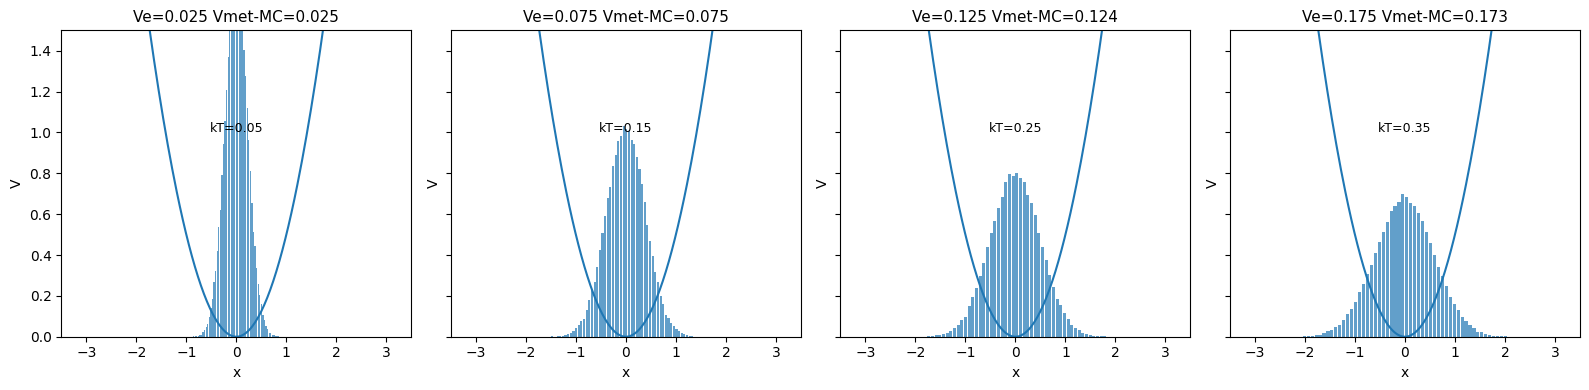

In [55]:
spring = Spring(k=1.0)
spring.plot_temperature_series(temperatures=[0.05, 0.15, 0.25, 0.35])

In [56]:
def velocity_verlet (mdsys , N=100):
    rs = []
    dt = 0.01
    for _ in range(N):
        r = mdsys.get_position()
        v = mdsys.get_velocity()
        a_t = mdsys.force()

        r +=  v*dt + .5 * a_t*dt**2 # YOUR CODE
        mdsys.set_position (r)

        # YOUR CODE GETTING THE FORCE
        a_t_next = mdsys.force()

        v += 0.5 * (a_t + a_t_next) * dt
        mdsys.set_velocity(v)
        
        rs.append(r)
    return rs

In [57]:
class MolDynSystem ():
    def __init__ (self,calc,x=0,kT =0.15):
        self.calc = calc
        self.x = x
        self.v = 0
        self.kT = kT

    def potential_energy (self):
        return self.calc.potential_energy (self.x)

    def force(self):
        return self.calc.force(self.x)

    def get_position (self):
        return self.x

    def set_position (self ,x):
        self.x = x

    def get_velocity (self):
        return self.v

    def set_velocity (self ,v):
        self.v = v

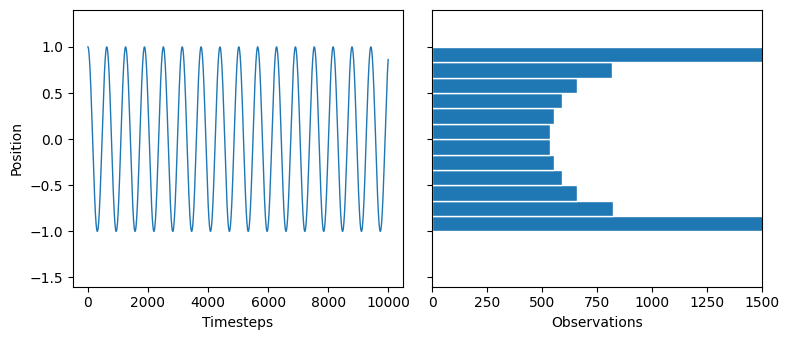

In [58]:
md = MolDynSystem(spring,x=1)
xs = velocity_verlet(md,N =10000)


timesteps = np.arange(len(xs))

# Create side-by-side subplots sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)

# Left plot: Trajectory
ax1.plot(timesteps, xs, linewidth=1)
ax1.set_xlabel('Timesteps')
ax1.set_ylabel('Position')
ax1.set_ylim(-1.6, 1.4)

# Right plot: Horizontal Histogram (binned strictly within [-1, 1])
ax2.hist(
    xs, 
    bins=12, 
    range=(-1, 1), 
    orientation='horizontal', 
    edgecolor='white'
)
ax2.set_xlabel('Observations')
ax2.set_xlim(0, 1500)

plt.tight_layout()
plt.show()

In [59]:
def andrea_anderson_thermostat(md, kT, m=1):
    sigma = np.sqrt(kT / m)
    v = np.random.normal(0,sigma)
    md.set_velocity(v)

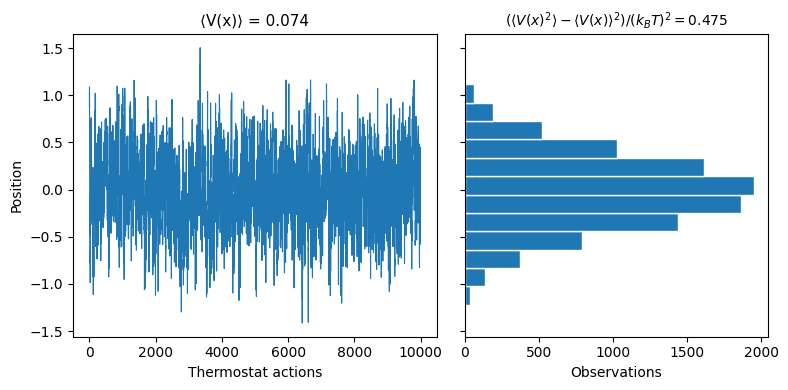

In [62]:
md = MolDynSystem (spring ,x=1)
xs = []
for _ in range (10000) :
    # do 50 constant energy steps
    x = velocity_verlet(md, 50)
    # add the final position to your sample
    xs.append(x[-1])
    # apply the thermostat
    andrea_anderson_thermostat (md, .15)
# finally , plot xs

xs = np.array(xs)
kbT = 0.15
V_pot = 0.5 * 1.0 * (xs**2)  # V = 1/2 * k * x^2

# Calculate thermal average and heat capacity
v_mean = np.mean(V_pot)
v_var = np.mean(V_pot**2) - (v_mean**2)
Cv_kb = v_var / (kbT**2)

# Subplot layout matching assignment
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharey=True, gridspec_kw={'width_ratios': [1.2, 1]})

# Trajectory
ax1.plot(xs, linewidth=0.8)
ax1.set_xlabel('Thermostat actions')
ax1.set_ylabel('Position')
ax1.set_title(f"⟨V(x)⟩ = {v_mean:.3f}", fontsize=11)

# Horizontal Histogram
ax2.hist(xs, bins=15, orientation='horizontal', color='tab:blue', edgecolor='white')
ax2.set_xlabel('Observations')
ax2.set_title(r"$(\langle V(x)^2 \rangle - \langle V(x) \rangle^2) / (k_B T)^2 = $" + f"{Cv_kb:.3f}", fontsize=10)

plt.tight_layout()
plt.show()